#Problem 1: Mall Customer Segmentation
#Dataset: Mall Customer Segmentation

**Questions:**

1.Why do you need to scale the features before applying K-Means?


2.Use the Elbow method (K=1 to 10). What is the optimal number of clusters?


3.Train K-Means with K=5. How many customers are in each cluster?


4.What are the cluster center coordinates for K=5?

5.Which cluster would you target for luxury products and why?


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
df = pd.read_csv("Mall_Customers.csv")
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# 1 no solve :

K-Means distance (Euclidean Distance) ব্যবহার করে ক্লাস্টার তৈরি করে। যদি একটি feature-এর scale অনেক বড় হয় (যেমন Income = 100000) এবং অন্যটি ছোট হয় (যেমন Age = 20), তাহলে বড় scale-এর feature পুরো clustering-কে dominate করবে।

Feature scaling (StandardScaler বা MinMaxScaler) করলে সব feature একই scale-এ আসে, ফলে প্রতিটি feature সমান গুরুত্ব পায় এবং clustering আরও ভালো হয়।


#Short Answer:

Feature scaling is required because K-Means uses Euclidean distance. Scaling makes all features have the same range so that no feature dominates the clustering process.






In [ ]:
inertia = []

for k in range(1,11):
    model = KMeans(
        n_clusters=k,
        init='k-means++',
        max_iter=400,
        random_state=42
    )

    model.fit(X_scaled)
    inertia.append(model.inertia_)

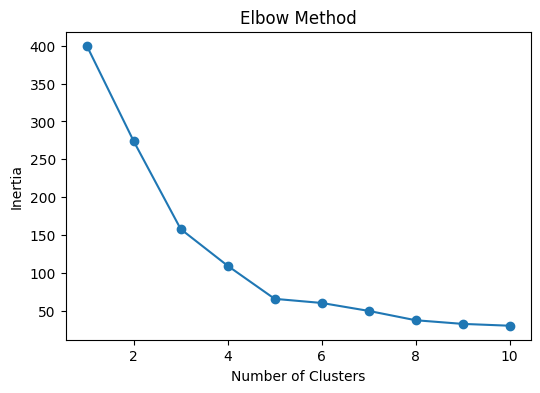

In [ ]:
plt.figure(figsize=(6,4))

plt.plot(range(1,11), inertia, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

#**Q2. Use the Elbow Method (K=1 to 10). What is the optimal number of clusters?**

Answer:

The Elbow Method is used to find the optimal number of clusters. The point where the inertia starts decreasing slowly is chosen as the optimal K. For this dataset, the optimal number of clusters is 5 (if your elbow graph shows 5).

In [ ]:
# 3 solve
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    max_iter=400,
    random_state=42
)

kmeans.fit(X_scaled)

KMeans(max_iter=400, n_clusters=5, random_state=42)

In [ ]:
df['Cluster'] = kmeans.labels_
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [ ]:
df['Cluster'].value_counts()

,count
Cluster,
0,81
1,39
3,35
4,23
2,22


In [ ]:
# 4 no solve


kmeans.cluster_centers_

array([[-0.20091257, -0.02645617],
       [ 0.99158305,  1.23950275],
       [-1.32954532,  1.13217788],
       [ 1.05500302, -1.28443907],
       [-1.30751869, -1.13696536]])

In [ ]:
print("Inertia :", kmeans.inertia_)

Inertia : 65.56840815571681


# **Answer: 5 no solve**

I would target the cluster with the highest annual income and highest spending score, because these customers have high purchasing power and are more likely to buy luxury products.

তুমি বলছো:

> **"Unsupervised-এ তো আগে থেকে Group জানা থাকে না। তাহলে A, B, C একই Cluster-এ আছে কীভাবে ধরলে?"**

উত্তর হলো: **আমি উদাহরণ দেওয়ার জন্য ধরেছিলাম। বাস্তবে K-Means নিজেই Group বানায়।**

---

### K-Means আসলে কী করে?

ধরো তোমার Data হলো

| Customer | Income | Spending |
| -------- | ------ | -------- |
| A        | 15     | 39       |
| B        | 16     | 42       |
| C        | 17     | 40       |
| D        | 80     | 90       |
| E        | 82     | 88       |

এখন K-Means-কে বললে

```python
K = 2
```

সে **জানে না** কে কোন Group-এ।

প্রথমে সে **দুইটা Centroid Randomly** নেয়।

ধরো

```text
Centroid 1 = (16,40)

Centroid 2 = (81,89)
```

এরপর প্রতিটি Customer-এর Distance হিসাব করে।

দেখে

* A → Centroid 1-এর কাছে
* B → Centroid 1-এর কাছে
* C → Centroid 1-এর কাছে
* D → Centroid 2-এর কাছে
* E → Centroid 2-এর কাছে

তখন **নিজেই** Group বানায়।

```text
Cluster 0
A
B
C

Cluster 1
D
E
```

এরপর প্রতিটি Cluster-এর Average বের করে নতুন Centroid বানায়।

আবার Distance হিসাব করে।

আবার Average বের করে।

এভাবে Centroid আর পরিবর্তন না হওয়া পর্যন্ত চলতে থাকে।

---

### তাই

আমি আগে যে A, B, C একসাথে লিখেছিলাম,

**ওটা K-Means-এর Final Result-এর উদাহরণ ছিল**, আগে থেকে জানা Group না।

---

### Viva-তে যদি Sir জিজ্ঞেস করেন

**Q: Does K-Means know the groups before training?**

**Answer:**

> **No. K-Means does not know the groups beforehand. It randomly initializes centroids, assigns data points to the nearest centroid, updates the centroids, and repeats the process until the clusters become stable.**





# Problem 2: Iris Dataset Clustering
# Dataset: Iris Dataset

Questions:

1.Scale the 4 features. Why is scaling necessary?


2.Use the Elbow method and Silhouette Score to find optimal K. What is the best K?


3.Train K-Means with K=3. How many samples in each cluster?


Compare K-Means labels with actual species. Which cluster matches Setosa?


In [ ]:
from sklearn.datasets import load_iris
df=load_iris(as_frame=True).frame

df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [ ]:
x =df[['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']]

scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)



In [ ]:
inertia = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        init='k-means++',
        max_iter=400,
        random_state=42
    )

    model.fit(x_scaled)

    inertia.append(model.inertia_)

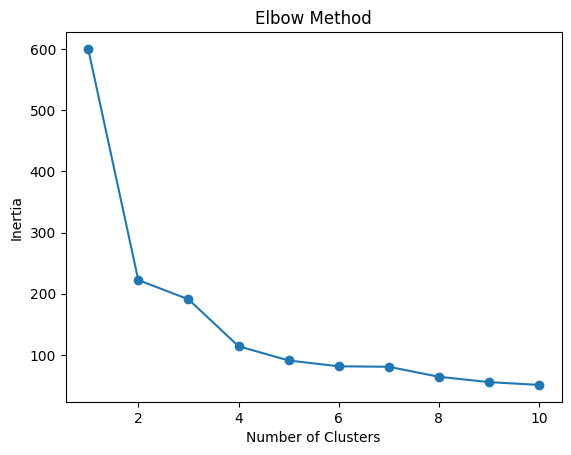

In [ ]:
plt.plot(range(1,11), inertia, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

Elbow Method-এ আমরা এমন Point খুঁজি যেখানে Graph-এর বাঁক (bend) সবচেয়ে স্পষ্ট হয় এবং এরপর থেকে Inertia ধীরে ধীরে কমতে থাকে।

তোমার Graph-এ:

K=1 → K=2  🔽 অনেক কমেছে
K=2 → K=3  🔽 অনেক কমেছে
K=3 → K=4  🔽 কমেছে
K=4 → K=5  🔽 কমেছে
K=5 → K=6  ➖ খুব অল্প কমেছে
K=6 → K=7  ➖ অল্প
K=7 → K=8  ➖ অল্প

এখানে K = 5-এর পর Graph প্রায় সমান (flat) হয়ে যাচ্ছে।

তাই Elbow = K = 5।

সহজ নিয়ম

✅ বাঁক (Elbow) যেখানে সবচেয়ে স্পষ্ট, সেটাই Optimal K।

❌ শেষের সবচেয়ে কম Inertia দেখে K নির্বাচন করবে না।

Viva-তে যদি Sir জিজ্ঞেস করেন

Sir: How did you choose K=5?

Answer:

I used the Elbow Method. I plotted K versus Inertia and selected the point where the curve bends and the decrease in Inertia becomes much slower. In my graph, that point is K = 5.




In [ ]:
from sklearn.metrics import silhouette_score
silhouette_scores = []

for k in range(2,11):

    modal = KMeans(
        n_clusters=k,
        init='k-means++',
        max_iter=400,
        random_state=42
    )

    labels = modal.fit_predict(x_scaled)

    score = silhouette_score(x_scaled, labels)

    silhouette_scores.append(score)

    print(f"K={k} : {score}")

K=2 : 0.5817500491982808
K=3 : 0.4798814508199818
K=4 : 0.3850454053045392
K=5 : 0.34503345350274617
K=6 : 0.33394323040061763
K=7 : 0.2664290993719981
K=8 : 0.34162906041313373
K=9 : 0.3243991438983545
K=10 : 0.33540615043919825


In [ ]:
print(df.shape)
print(x.shape)
print(x_scaled.shape)

(150, 5)
(150, 4)
(150, 4)


In [ ]:
modal= KMeans(
    n_clusters=3,# question basis e k=3 nilam
    init="k-means++",
    max_iter=400,
    random_state=42
)

modal.fit(x_scaled)

KMeans(max_iter=400, n_clusters=3, random_state=42)

In [ ]:
df['Cluster'] = modal.labels_

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,Cluster
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,2
2,4.7,3.2,1.3,0.2,0,2
3,4.6,3.1,1.5,0.2,0,2
4,5.0,3.6,1.4,0.2,0,1


In [ ]:
df['Cluster'].value_counts()

,count
Cluster,
0,96
1,33
2,21


In [ ]:
modal.cluster_centers_

array([[ 0.57100359, -0.37176778,  0.69111943,  0.66315198],
       [-0.81623084,  1.31895771, -1.28683379, -1.2197118 ],
       [-1.32765367, -0.373138  , -1.13723572, -1.11486192]])

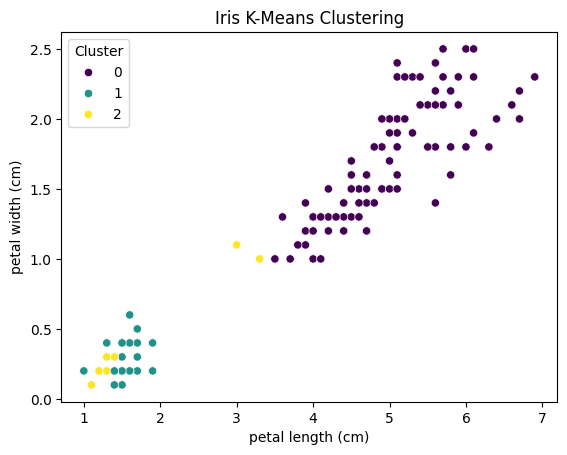

In [ ]:
sns.scatterplot(
    x=df['petal length (cm)'],
    y=df['petal width (cm)'],
    hue=df['Cluster'],
    palette='viridis'
)

plt.title("Iris K-Means Clustering")

plt.show()

In [ ]:
print(modal.inertia_)

191.02473685317952


# K kirkm nibo setar basis e

এটাই K-Means-এর সবচেয়ে গুরুত্বপূর্ণ বিষয়। তুমি ঠিক জায়গাতেই আটকে গেছো।

তুমি বলছো:

> **K=3 হলে Inertia = 192, কিন্তু K=10 হলে Inertia = 50। তাহলে K=10-ই তো ভালো?**

**উত্তর: না।** কারণ Inertia **K বাড়ার সাথে সাথে প্রায় সবসময় কমে।**

### সহজ উদাহরণ

ধরো তোমার কাছে ১০০ জন Student আছে।

### K = 2

২টা Group।

প্রতি Group-এ প্রায় ৫০ জন।

অনেক Student Center থেকে দূরে থাকবে।

➡️ Inertia = বেশি

---

### K = 10

১০টা Group।

প্রতি Group-এ প্রায় ১০ জন।

Student-রা তাদের Center-এর অনেক কাছে থাকবে।

➡️ Inertia = কম

---

### K = 100

১০০টা Group।

প্রতি Student-এর নিজের আলাদা Cluster।

তখন প্রত্যেক Student তার Center-এর উপরই থাকবে।

➡️ **Inertia = 0** (বা প্রায় 0)

কিন্তু এটা কি ভালো Clustering?

**না।**

কারণ Cluster এত বেশি হয়ে গেছে যে Clustering-এর উদ্দেশ্যই নষ্ট হয়ে গেছে।

---

## তাই আমরা কী করি?

আমরা **সর্বনিম্ন Inertia খুঁজি না**।

আমরা এমন K খুঁজি যেখানে:

* Cluster খুব কমও নয়।
* Cluster অযথা খুব বেশিও নয়।

এই Balance খুঁজতেই **Elbow Method** ব্যবহার করা হয়।

---

### মনে রাখার নিয়ম

* ✅ **K বাড়লে Inertia কমবে** — এটা স্বাভাবিক।
* ❌ **সবচেয়ে কম Inertia মানেই Best K নয়।**

তাই K=10-এ Inertia 50 হওয়া স্বাভাবিক, কিন্তু তাই বলে K=10-ই Best হবে—এমন নয়।

এ কারণেই Elbow Graph আর Silhouette Score একসাথে ব্যবহার করা হয়।


অবশ্যই। আমি **K-Means Clustering** একদম শুরু থেকে এমনভাবে বুঝাচ্ছি, যেন তুমি viva-তেও উত্তর দিতে পারো।

---

# ১. K-Means কী?

K-Means একটি **Unsupervised Machine Learning Algorithm**।

**Unsupervised** মানে Dataset-এ **Target/Label ব্যবহার করা হয় না**।

এর কাজ হলো একই ধরনের Data-কে বিভিন্ন **Cluster (Group)**-এ ভাগ করা।

---

# ২. K (K=3, K=5) মানে কী?

K মানে **কয়টি Cluster বানাবে**।

উদাহরণ:

```text
K = 2 → ২টি Cluster
K = 3 → ৩টি Cluster
K = 5 → ৫টি Cluster
```

তুমি যখন লিখো

```python
KMeans(n_clusters=3)
```

মানে Model-কে বলছো:

> "এই Data-কে ৩টি Group-এ ভাগ করো।"

---

# ৩. Feature কী?

Feature মানে Input Column।

যেমন Iris Dataset:

| Feature      |
| ------------ |
| sepal length |
| sepal width  |
| petal length |
| petal width  |

এই ৪টা Feature দিয়ে K-Means Data-র similarity বের করে।

---

# ৪. Scaling কেন করি?

```python
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
```

K-Means **Euclidean Distance** ব্যবহার করে।

যদি এক Feature-এর মান অনেক বড় হয়, তাহলে সেটাই Distance-কে বেশি প্রভাবিত করবে।

তাই সব Feature-কে একই Scale-এ আনা হয়।

---

# ৫. `init='k-means++'` কী?

```python
init='k-means++'
```

এর কাজ হলো **শুরুর Centroid (Center) Smartভাবে নির্বাচন করা।**

ফলে

* ভালো Result
* দ্রুত Training

---

# ৬. `max_iter=400`

মানে

সর্বোচ্চ 400 বার পর্যন্ত Centroid Update করবে।

যদি তার আগেই Stable হয়ে যায়, তাহলে 400 পর্যন্ত যাবে না।

---

# ৭. `random_state=42`

এটা দিলে

প্রতিবার একই Result পাওয়া যায়।

---

# ৮. Centroid কী?

Centroid = Cluster-এর Center।

যদি K=3 হয়

তাহলে

```text
Cluster 0 → একটি Center

Cluster 1 → একটি Center

Cluster 2 → একটি Center
```

এই Center-গুলোই

```python
kmeans.cluster_centers_
```

---

# ৯. `kmeans.labels_`

```python
kmeans.labels_
```

প্রতিটি Data কোন Cluster-এ গেছে সেটা বলে।

যেমন

```text
0
0
2
1
1
2
```

মানে

১ম Data → Cluster 0

২য় Data → Cluster 0

৩য় Data → Cluster 2

...

---

# ১০. Inertia কী?

```python
kmeans.inertia_
```

Inertia =

> প্রতিটি Data তার নিজের Centroid থেকে কত দূরে আছে, তার মোট Distance।

### মনে রাখো

**কম Inertia = ভালো।**

---

# ১১. Elbow Method কী?

এটা ব্যবহার করা হয়

**Best K বের করার জন্য।**

Code

```python
for k in range(1,11):
```

মানে

K=1

K=2

K=3

...

K=10

সবগুলোর Inertia বের করবে।

---

## Elbow Graph

```text
Inertia

500 ●

400 |

300 |     ●

200 |         ●

100 |             ●

 80 |                ●
                    \
 70 |                 ●
 68 |                  ●

----------------------------

1 2 3 4 5 6 7 8 9 10
```

যেখানে Graph বাঁক নেয়

ওটাই

**Optimal K**

---

# ১২. Silhouette Score কী?

এটা Clustering কত ভালো হয়েছে সেটা বলে।

Range

```text
-1 -------- 0 -------- 1
```

**১-এর কাছাকাছি = সবচেয়ে ভালো।**

---

Code

```python
score = silhouette_score(X_scaled, labels)
```

---

# ১৩. Silhouette Graph

তুমি Graph না এঁকে শুধু Score Print করেছো।

যেমন

```text
K=2 → 0.58

K=3 → 0.66

K=4 → 0.55

K=5 → 0.49
```

এখানে

সবচেয়ে বড়

```text
0.66
```

তাই

Best K = 3

---

# ১৪. Scatter Plot

```python
sns.scatterplot(...)
```

এটা Data-কে দেখানোর জন্য।

প্রতিটি রঙ = একটি Cluster।

---

# ১৫. Cluster Center

```python
kmeans.cluster_centers_
```

যদি K=3 হয়

তাহলে

```text
3টি Row
```

কারণ

৩টি Cluster।

যদি K=5

তাহলে

```text
5টি Row
```

---

# সবচেয়ে গুরুত্বপূর্ণ Viva প্রশ্ন

| প্রশ্ন                          | উত্তর                                            |
| ------------------------------- | ------------------------------------------------ |
| K-Means কী?                     | Unsupervised Clustering Algorithm                |
| K কী?                           | Number of Clusters                               |
| Scaling কেন?                    | K-Means uses Euclidean Distance                  |
| `init='k-means++'`              | Smart centroid initialization                    |
| Inertia                         | Sum of squared distances to the nearest centroid |
| Elbow Method                    | Best K খুঁজতে ব্যবহার করা হয়                     |
| Silhouette Score                | Clustering quality measure                       |
| Inertia কেমন হলে ভালো?          | কম হলে ভালো                                      |
| Silhouette Score কেমন হলে ভালো? | বেশি হলে ভালো                                    |
| `cluster_centers_`              | প্রতিটি Cluster-এর Centroid                      |
| `labels_`                       | প্রতিটি Data কোন Cluster-এ গেছে                  |


